In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("data/cleaned_customers.csv")

print(df.shape)

(53503, 23)


In [3]:
sample_df = df.sample(
    n=5000,
    random_state=42
)

sample_df.shape

(5000, 23)

In [4]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = sample_df[features]

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5000, 4)


In [6]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

clusters = dbscan.fit_predict(
    X_scaled
)

sample_df["DBSCAN_Cluster"] = clusters

print("DBSCAN Completed")

DBSCAN Completed


In [7]:
sample_df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
0    5000
Name: count, dtype: int64

In [8]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

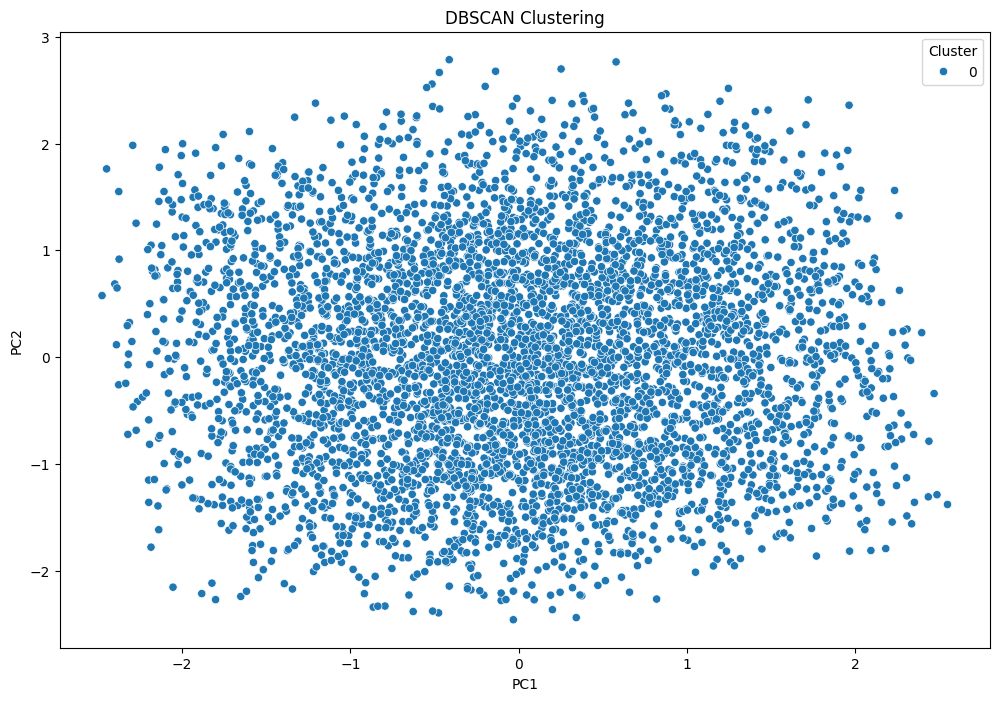

In [9]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("DBSCAN Clustering")

plt.show()

In [10]:
dbscan_profile = sample_df.groupby(
    "DBSCAN_Cluster"
)[
    [
        "Age",
        "Income Level",
        "Coverage Amount",
        "Premium Amount"
    ]
].mean()

dbscan_profile.round(2)

,Age,Income Level,Coverage Amount,Premium Amount
DBSCAN_Cluster,,,,
0,44.27,82758.86,495539.4,3037.24


In [11]:
dbscan_profile.to_csv(
    "reports/dbscan_cluster_profile.csv"
)

sample_df.to_csv(
    "data/dbscan_clustered_customers.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [12]:
dbscan_profile.round(2)

,Age,Income Level,Coverage Amount,Premium Amount
DBSCAN_Cluster,,,,
0,44.27,82758.86,495539.4,3037.24
